<a href="https://colab.research.google.com/github/pozdnyavladimer-jpg/v-kernel/blob/main/notebooks/diffusion_inhibition_gate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

D5_INHIBITION — Diffusion Suppression Gate

Status

Working prototype.

Purpose

This notebook demonstrates a diffusion-based inhibition gate.

Unlike the AND gate, where two fields create a stable output through overlap, this experiment makes the overlap destructive.

When only one input is active, the field stabilizes.

When both inputs are active, the interaction zone suppresses the output.

Result

A| B| State| Output
0| 0| EMPTY| 0
1| 0| STABLE| 1
0| 1| STABLE| 1
1| 1| SUPPRESSED| 0

Interpretation

A single active input can stabilize the field.

Two active inputs create a conflict zone.

The conflict zone suppresses the output field instead of strengthening it.

This means the system behaves as a diffusion-based inhibition gate:

one active input → stable field

two active inputs → suppressed field

Diffusion Alphabet Mapping

Symbol:

D5_INHIBITION

Family:

Logic / Suppression / Conflict

Meaning:

A two-field system where each individual input can create a stable output, but the overlap between both fields suppresses the output.

Field Architecture

Input A creates field X.

Input B creates field Y.

The output field Z grows from individual field activity.

The overlap between X and Y creates a conflict zone.

The conflict zone reduces or destroys the output field.

In simple form:

single field → growth

overlap of two fields → suppression

Observed Output

The experiment produced:

A=0 B=0 → EMPTY

A=1 B=0 → STABLE

A=0 B=1 → STABLE

A=1 B=1 → SUPPRESSED

This confirms that D5_INHIBITION is a working diffusion alphabet symbol.

Relation to Previous Experiments

Previous symbols:

D3_OR_STABLE

A single-field system where one or more active inputs stabilize the field.

D4_AND_OVERLAP

A two-field system where stable output appears only from overlap.

Current symbol:

D5_INHIBITION

A two-field system where overlap suppresses the output.

Repository Name

Recommended notebook filename:

notebooks/diffusion_inhibition_gate.ipynb

Experiment Label

Experiment 03 — Diffusion Inhibition / Conflict Suppression

Commit Message

Add diffusion inhibition gate prototype

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def laplacian(Z):
    return (
        -4 * Z
        + np.roll(Z, 1, axis=0)
        + np.roll(Z, -1, axis=0)
        + np.roll(Z, 1, axis=1)
        + np.roll(Z, -1, axis=1)
    )

def make_inhibition_fields(a=0, b=0, size=100):
    X = np.zeros((size, size), dtype=float)
    Y = np.zeros((size, size), dtype=float)

    # A створює поле X
    if a == 1:
        X[45:55, 35:45] = 1.0

    # B створює поле Y
    if b == 1:
        Y[45:55, 55:65] = 1.0

    return X, Y

In [ ]:
def diffuse_inhibition_gate(
    X,
    Y,
    steps=220,
    diffusion=0.20,
    field_decay=0.006,
    output_diffusion=0.12,
    growth=0.45,
    output_decay=0.015,
    conflict_penalty=2.2,
    burn=0.8
):
    X = X.copy()
    Y = Y.copy()
    Z = np.zeros_like(X)

    for _ in range(steps):
        # два вхідні поля дифундують окремо
        X = X + diffusion * laplacian(X) - field_decay * X
        Y = Y + diffusion * laplacian(Y) - field_decay * Y

        X = np.clip(X, 0, 1)
        Y = np.clip(Y, 0, 1)

        # зона конфлікту: там, де X і Y зустрілись
        conflict = np.sqrt(X * Y)

        # підтримка росту є, коли активне X або Y
        # але при перетині X і Y підтримка знищується
        drive = np.clip((X + Y) - conflict_penalty * conflict, 0, 1)

        gate_drive = np.zeros_like(Z)
        gate_conflict = np.zeros_like(Z)

        gate_drive[40:60, 40:60] = drive[40:60, 40:60]
        gate_conflict[40:60, 40:60] = conflict[40:60, 40:60]

        # Z росте від одного сигналу,
        # але випалюється, коли два сигнали перетинаються
        Z = (
            Z
            + output_diffusion * laplacian(Z)
            + growth * gate_drive
            - output_decay * Z
            - burn * gate_conflict
        )

        Z = np.clip(Z, 0, 1)

    return X, Y, Z


def detect_inhibition_state(Z, a, b):
    total_mass = float(Z.sum())
    center_mass = float(Z[40:60, 40:60].sum())
    max_value = float(Z.max())

    if total_mass < 1.0 and a == 0 and b == 0:
        return "EMPTY"

    if center_mass > 20.0 and max_value > 0.05:
        return "STABLE"

    return "SUPPRESSED"

A: 0 B: 0
STATE: EMPTY


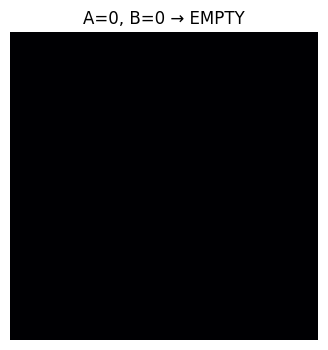

A: 1 B: 0
STATE: STABLE


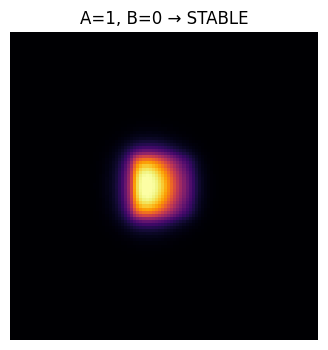

A: 0 B: 1
STATE: STABLE


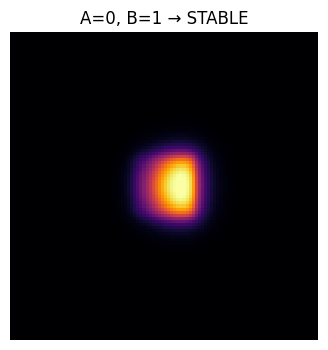

A: 1 B: 1
STATE: SUPPRESSED


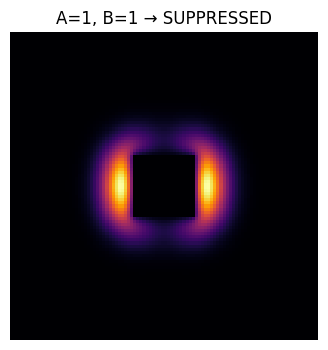

,A,B,state,output,mass,center,max
0,0,0,EMPTY,0,0.000,0.000,0.000
1,1,0,STABLE,1,323.251,241.144,1.000
2,0,1,STABLE,1,323.251,241.144,1.000
3,1,1,SUPPRESSED,0,16.015,0.000,0.034


In [ ]:
cases = [(0, 0), (1, 0), (0, 1), (1, 1)]
results = []

for a, b in cases:
    X0, Y0 = make_inhibition_fields(a, b)
    X, Y, Z = diffuse_inhibition_gate(X0, Y0)
    state = detect_inhibition_state(Z, a, b)

    results.append({
        "A": a,
        "B": b,
        "state": state,
        "output": 1 if state == "STABLE" else 0,
        "mass": round(float(Z.sum()), 3),
        "center": round(float(Z[40:60, 40:60].sum()), 3),
        "max": round(float(Z.max()), 3),
    })

    print("====================")
    print("A:", a, "B:", b)
    print("STATE:", state)

    plt.figure(figsize=(4, 4))
    plt.imshow(Z, cmap="inferno")
    plt.title(f"A={a}, B={b} → {state}")
    plt.axis("off")
    plt.show()

df = pd.DataFrame(results)
df